# Example: HLT tracking DQM validation with `TrackingDQMPlotter`

This notebook needs real CMS DQM ROOT files and won't run out of the box —
see [`quickstart_histograms.ipynb`](quickstart_histograms.ipynb) instead for
an example that works with no external data. It expects, relative to the
current working directory:

    data/Tracking/DQM_TTbarPU200_<tag>.root

for every `<tag>` used in `CONFIGURATIONS` below, each containing the path
`DQMData/Run 1/HLT/Run summary/Tracking/ValidationWRTtp` (the standard
layout produced by the CMS tracking DQM harvesting step). Adjust
`CONFIGURATIONS`, `DATAPATH`, or `FILENAMEPREFIX` to match your own files —
see `TrackingDQMPlotter`'s docstring for details.

The notebook covers two common workflows:

1. **Comparing configurations for one track collection** — the everyday case.
2. **Overlaying different track collections** (e.g. pixel and general tracks)
   for the same run, with per-curve label and color overrides.

In [1]:
from cmsplot.dqm import TrackingDQMPlotter

## Set up the  `TrackingDQMPlotter`

DQM validation plotter for CMS HLT pixel and general tracking.

Reads tracking-validation ROOT files produced by the CMS DQM framework and
provides efficiency, fake-rate, duplicate-rate, resolution, and hit-count
histograms for comparison across reconstruction configurations.

Two track collections are available by default:

- ``"GeneralTracks"`` — general-purpose HLT tracks (``hltGeneral``).
- ``"PixelTracks"`` — Phase-2 high-purity pixel tracks (``hltPhase2Pixel``).

By default, ROOT files are expected at ``data/Tracking/DQM_Tracking_<tag>.root``,
inside the path ``DQMData/Run 1/HLT/Run summary/Tracking/ValidationWRTtp``.

In [2]:
plotter = TrackingDQMPlotter(
    CONFIGURATIONS={
        # tag               color       legend label
        "LegacyBaseline":  ["#A3A2A2", "Legacy baseline"],
        "CurrentBaseline": ["#E15050", "Current baseline"],
        "ITACA":           ["#346ED9", "ITACA"],
    },
    DATAPATH="data/Tracking/",         # set the path to the data files
    FILENAMEPREFIX="DQM_TTbarPU200_",  # change the filename prefix
)

## Plotting all curves for one track collection

The most common case: compare several reconstruction configurations for a
*single* track collection. Pass the collection name as a plain string to
`PLOTTINGCONFIGURATION` — one line is drawn per entry in `CONFIGURATIONS`,
with its legend label and color taken directly from there. Call
`setPlottingConfiguration` again whenever you want to change what's being
compared (a different collection, a different set of configs, or per-curve
label/color overrides — see the overlay section further down) since it
rebuilds the plotter's internal state.

In [3]:
# one line per config, comparing pixel tracks in this case
plotter.setPlottingConfiguration(
    PLOTTINGCONFIGURATION="PixelTracks",
    CMSLABEL="Simulation (Private Work)",
    DATALABEL=r"$\text{t}\bar{\text{t}}$ + 200 PU ($\sqrt{s} = 14\,\text{TeV}$)",
    OBJECTLABEL="HLT Pixel Tracks",
    DIR="plots/Tracking/PixelTracks",
    SAVEAS=["png", "pdf"],
    DRAFT=True,
)

Before picking a histogram key, list what's actually available for this
collection together with its underlying ROOT source — useful to sanity-check
that everything loaded correctly and to look up the exact key for a
histogram you don't remember the name of. `plotHistogram` also prints a
one-line reminder of the source it's plotting, every time it's called.

In [4]:
# see what's available before plotting
plotter.listHistograms("PixelTracks")


Collection: PixelTracks
  Key                 ROOT source
  ------------------  ---------------------------------------------
  effVsEta            efficiency | eta
  effVsPt             efficiency | pt
  effVsPhi            efficiency | phi
  effVsVertex         effic_vs_vertpos
  fakeVsEta           fake | eta
  fakeVsPt            fake | pt
  fakeVsPhi           fake | phi
  dupVsEta            duplicate | eta
  dupVsPt             duplicate | pt
  dupVsPhi            duplicate | phi
  ptResVsEta          ptres_vs_eta_Sigma
  ptResVsPt           ptres_vs_pt_Sigma
  phiResVsEta         phires_vs_eta_Sigma
  dxyResVsEta         dxyres_vs_eta_Sigma
  dzResVsEta          dzres_vs_eta_Sigma
  etaResVsEta         etares_vs_eta_Sigma
  recoAssocVsEta      num_assoc(recoToSim)_eta
  recoAssocVsPt       num_assoc(recoToSim)_pT
  nTracksVsEta        num_reco_eta
  nTracksVsPt         num_reco_pT
  nDupsVsEta          num_duplicate_eta
  nDupsVsPt           num_duplicate_pT
  hitsVsEta       

Efficiency vs. η for all three configurations overlaid. Cut labels
(`pT`, `|η|`, `|z_vertex|`, `r_vertex`) are appended to the right-hand label
automatically since `"eff"` appears in the histogram name.

Note that `yLim`'s upper bound needs enough headroom to fit the legend on
top of the data — it isn't added automatically (see `plotHistogram`'s
`yLim` docstring) — so it's set well above the physical `[0, 1]` efficiency
range.

Plot histogram:
'effVsEta'  [PixelTracks]  →  efficiency | eta
Saved plot to plots/Tracking/PixelTracks/effVsEta.png
Saved plot to plots/Tracking/PixelTracks/effVsEta.pdf


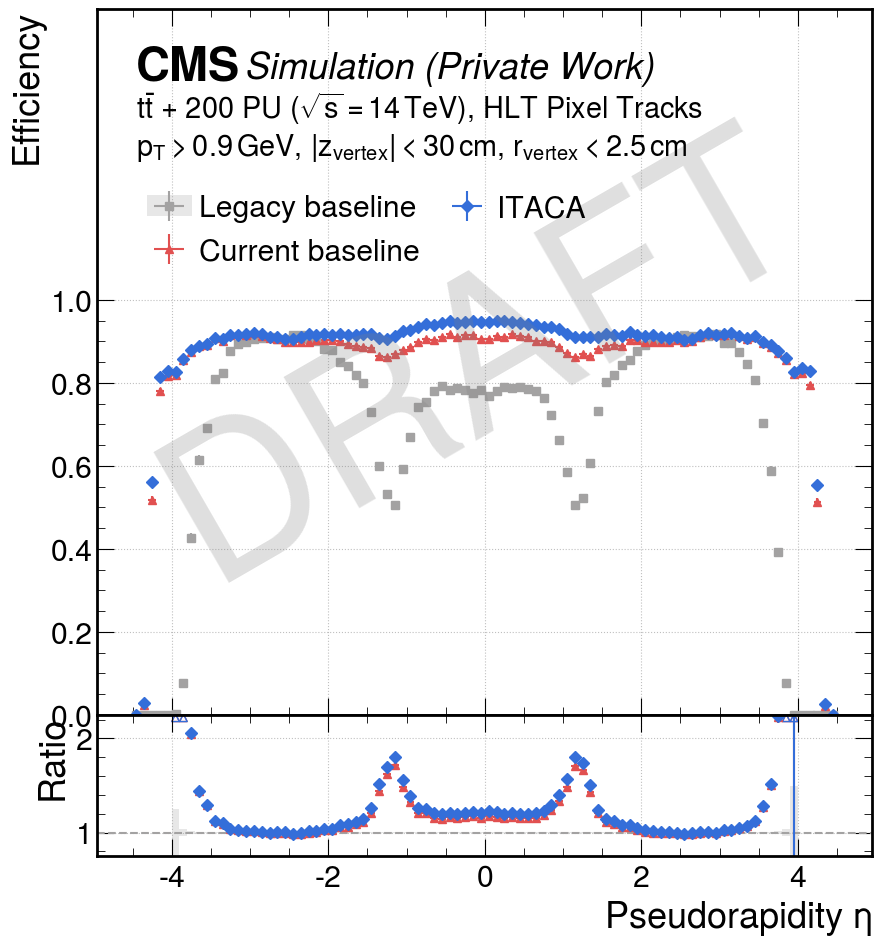

In [5]:
# efficiency vs eta - cut labels (pT, |eta|, |z_vertex|, r_vertex) are added automatically
plotter.plotHistogram(
    "effVsEta",
    yLim=(0., 1.7),
    ratioYLim=(0.75, 2.25),
    limitYTicks=True,
)

Fake rate vs. pT for the same three configurations — the x-axis switches to
log scale automatically since `"Pt"` appears in the histogram name.

Plot histogram:
'fakeVsPt'  [PixelTracks]  →  fake | pt
Saved plot to plots/Tracking/PixelTracks/fakeVsPt.png
Saved plot to plots/Tracking/PixelTracks/fakeVsPt.pdf


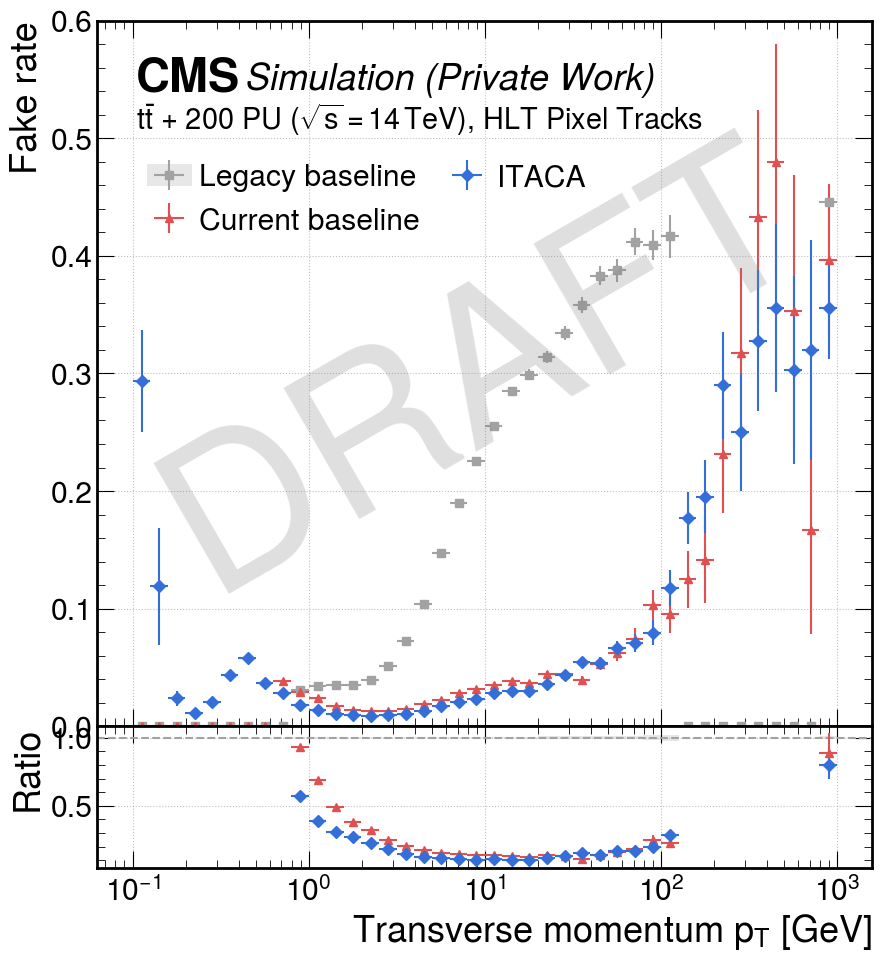

In [6]:
# fake rate vs pT - log x-axis is applied automatically for "Pt" histograms
plotter.plotHistogram("fakeVsPt", yLim=(0.0, 0.6))

### Derived histograms

`fakePlusDupVsEta`, `fakePlusDupVsPt`/`Phi`, and `nFakesVsEta`/`Pt` aren't
read directly from the ROOT file — `TrackingDQMPlotter.loadData` builds them
on the fly (`fakePlusDup = fake + dup`, `nFakes = nTracks - recoAssoc`) via
`getSumHist`/`getDiffHist`, with errors propagated in quadrature. They behave
like any other histogram key once loaded — `listHistograms` shows their
derivation instead of a ROOT path, e.g. `sum(fakeVsEta, dupVsEta)`.

Plot histogram:
'fakePlusDupVsEta'  [PixelTracks]  →  sum(fakeVsEta, dupVsEta)
Saved plot to plots/Tracking/PixelTracks/fakePlusDupVsEta.png
Saved plot to plots/Tracking/PixelTracks/fakePlusDupVsEta.pdf


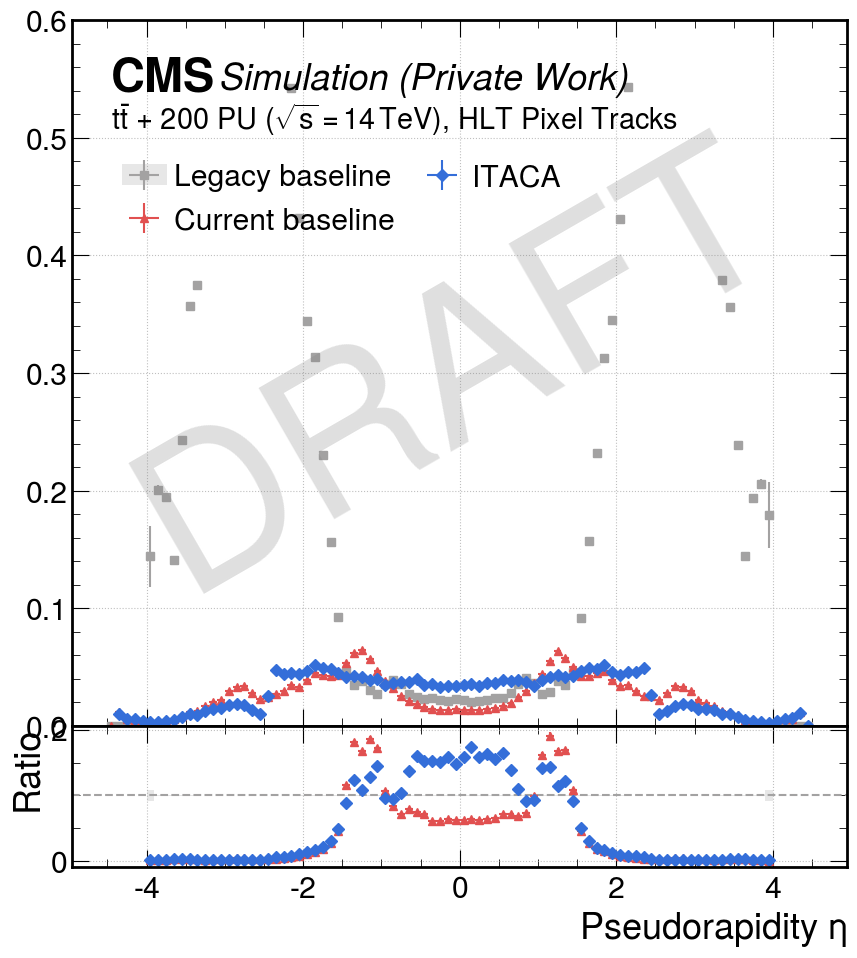

In [7]:
# fake + duplicate rate vs eta, combined into a single curve
plotter.plotHistogram("fakePlusDupVsEta", yLim=(0.0, 0.6))

## Plotting the overlay of different track collections

Sometimes one track collection alone isn't enough — e.g. to see how general
tracks pick up what pixel tracks miss for the same run. Pass a *list* of
`[config_tag, collection]` entries instead of a plain collection name, one
entry per curve:

- Every entry needs a **unique legend label**. By default the label is just
  `NAMES[config_tag]` (the label set in `CONFIGURATIONS`), so reusing the
  same `config_tag` for two collections — `"LegacyBaseline"` below, for both
  `"GeneralTracks"` and `"PixelTracks"` — would otherwise collide into a
  single label. A 3rd list element appends a distinguishing **label
  suffix** to disambiguate them (pass `None` to skip the suffix while still
  setting a color, see below). `setPlottingConfiguration` raises a
  `ValueError` if a collision slips through unnoticed, instead of silently
  dropping one of the curves.
- A 4th, optional list element **overrides that curve's color**, for when
  the config's default color would otherwise be shared, or just isn't the
  right choice for that particular curve — here `"LegacyBaseline"`'s
  general-track curve keeps its config color while its pixel-track curve is
  forced to black.
- Entries that are already unique (`"CurrentBaseline"`, `"ITACA"`) don't
  strictly need a suffix or color override — the plain 2-element form still
  works exactly like in the previous section, and is used here purely for a
  consistently formatted legend across all pixel-track curves.

The same mechanism (color override, without the suffix/list machinery) is
also available for the dict form of `PLOTTINGCONFIGURATION` — see the main
`README.md` for that variant.

In [8]:
plotter.setPlottingConfiguration(
    PLOTTINGCONFIGURATION=[
        # tag                collection         label suffix          color override
        ["LegacyBaseline",  "GeneralTracks",  "\n(General Tracks)"],
        ["LegacyBaseline",  "PixelTracks",    "\n(Pixel Tracks)",   "#000000"],
        ["CurrentBaseline", "PixelTracks",    "\n(Pixel Tracks)"],  # suffix only for consistent formatting, not needed for uniqueness
        ["ITACA",           "PixelTracks"],                          # already unique - no override needed at all
    ],
    CMSLABEL="Simulation (Private Work)",
    DATALABEL=r"$\text{t}\bar{\text{t}}$ + 200 PU ($\sqrt{s} = 14\,\text{TeV}$)",
    OBJECTLABEL="HLT Tracks",
    DIR="plots/Tracking/Overlay",
    SAVEAS=["png", "pdf"],
    DRAFT=True,
)

The same `"effVsEta"` histogram, now comparing four curves across two
different track collections. `yLabel`/`xLabel` override the automatic axis
labels, and `yLim`'s headroom is a bit larger than in the first section to
fit the extra legend entry.

Plot histogram:
'effVsEta'  [GeneralTracks]  →  efficiency | eta
'effVsEta'  [PixelTracks]  →  efficiency | eta
Saved plot to plots/Tracking/Overlay/effVsEta.png
Saved plot to plots/Tracking/Overlay/effVsEta.pdf


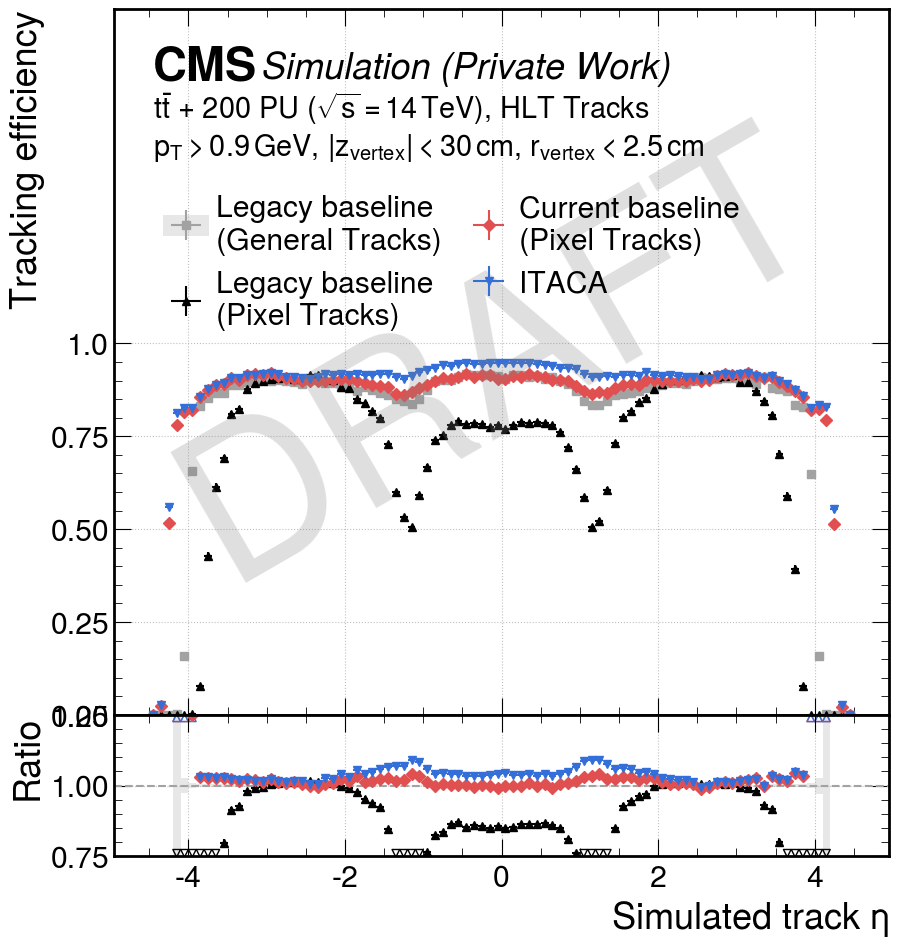

In [9]:
plotter.plotHistogram(
    "effVsEta",
    yLabel="Tracking efficiency",
    xLabel=r"Simulated track $\eta$",
    yLim=(0., 1.9),
    ratioYLim=(0.75, 1.25),
    limitYTicks=True,
)

Track $p_\text{T}$ resolution vs. η on a log y-axis (`yScale="log"`) — useful
since resolution typically spans orders of magnitude between the barrel and
the forward region. Resolution histograms aren't treated as efficiencies, so
no cut labels are appended to the right-hand label here. `xLim` is widened
beyond the nominal acceptance to show the low-statistics tails.

Plot histogram:
'ptResVsEta'  [GeneralTracks]  →  ptres_vs_eta_Sigma
'ptResVsEta'  [PixelTracks]  →  ptres_vs_eta_Sigma
Saved plot to plots/Tracking/Overlay/ptResVsEta.png
Saved plot to plots/Tracking/Overlay/ptResVsEta.pdf


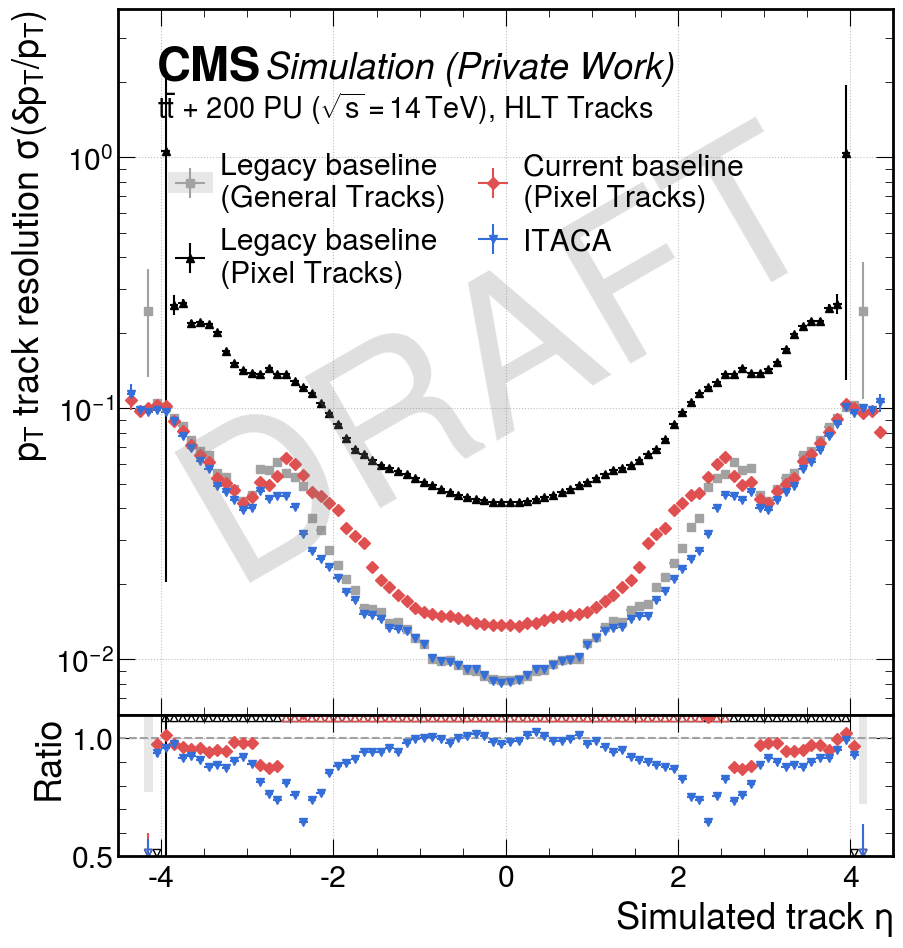

In [10]:
plotter.plotHistogram(
    "ptResVsEta",
    yLabel=r"$p_\text{T}$ track resolution $\sigma\left( \delta p_\text{T} / p_\text{T} \right)$",
    xLabel="Simulated track $\eta$",
    yLim=(0.6e-2,3.9),
    ratioYLim=(0.5, 1.1),
    xLim=(-4.5,4.5),
    limitYTicks=False,
    yScale="log"
)

## Next steps

- `SecondaryVertexingDQMPlotter` follows the same workflow for HLT secondary
  vertices — see `SecondaryVertexingDQMPlotter_example.py` in this directory.
- `quickstart_histograms.ipynb` covers the lower-level `Hist`/`getRatioHist`
  API directly, without a DQM plotter, using toy data.
- The main `README.md` has the full `setPlottingConfiguration`/
  `plotHistogram` option reference, plus more on comparing collections
  within the same config.